# Anharmonic phonon renormalisation with dynaphopy — EMT-Cu quick demo

A minimal end-to-end run of `calculate_phonon_md_renormalisation` (v0.0.8)
on FCC Cu with the EMT calculator, gated only on the `[phonons-md]` install
extra and runnable in CI's standard notebook environment.

For a more interesting example using a foundation model (GRACE-1L-OAM) and
a native LAMMPS MD driver side by side, see
[`dynaphopy_grace_example.ipynb`](dynaphopy_grace_example.ipynb).
That one is excluded from CI's `build-notebooks` job because it requires a
custom env with `tensorpotential` + a `pair_style grace`-capable LAMMPS
build.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.calculators.emt import EMT

## Structure + engines

FCC Cu seed structure (conventional 4-atom cubic — required because
`optimise_cubic_lattice_parameter` interprets `v0` as the volume of a
conventional cubic cell when computing `a0 = v0**(1/3)`). We use two
engines sharing the same EMT calculator: `engine_min` for the lat-opt
EOS scan (relaxation), and `engine_static` for the phonon-MD macro
(statics).

In [2]:
from pyiron_workflow_atomistics.engine import (
    ASEEngine,
    CalcInputMinimize,
    CalcInputStatic,
)

calculator = EMT()
cu = bulk("Cu", "fcc", a=3.6, cubic=True)  # 4-atom conventional, seed for EOS

engine_min = ASEEngine(
    EngineInput=CalcInputMinimize(
        force_convergence_tolerance=0.05, max_iterations=100
    ),
    calculator=calculator,
    working_directory="./_dynaphopy_emt_runs",
)
engine_static = ASEEngine(
    EngineInput=CalcInputStatic(),
    calculator=calculator,
    working_directory="./_dynaphopy_emt_runs",
)
print(f"Structure: {cu.get_chemical_formula()}  ({len(cu)} atoms)")

Structure: Cu4  (4 atoms)


## Wire lat-opt + phonon-MD into one Workflow

Parent `Workflow` does two things in order:

1. `optimise_cubic_lattice_parameter` runs a cheap 5-point EOS scan
   (strain range ±2 %) to remove any residual stress on the primitive
   cell before MD starts. Returns the equilibrium structure at the
   fitted `a0`.
2. `calculate_phonon_md_renormalisation` consumes that equilibrium
   structure with the static engine. `q_points=None` auto-derives a
   high-symmetry band path via `ase.dft.kpoints.bandpath`, returning a
   discretised dispersion of harmonic and renormalised frequencies.
   EMT-Cu is essentially harmonic so this primarily serves as an
   end-to-end workflow smoke test the CI can run cheaply.

In [3]:
from pyiron_workflow import Workflow
from pyiron_workflow_atomistics.physics.bulk import (
    optimise_cubic_lattice_parameter,
)
from pyiron_workflow_atomistics.physics.phonons import (
    calculate_phonon_md_renormalisation,
)

wf = Workflow("dynaphopy_emt")
wf.lat_opt = optimise_cubic_lattice_parameter(
    structure=cu,
    name="Cu",
    crystalstructure="fcc",
    engine=engine_min.with_working_directory("lat_opt"),
    strain_range=(-0.02, 0.02),
    num_points=5,
)
wf.phonon = calculate_phonon_md_renormalisation(
    structure=wf.lat_opt.outputs.equil_struct,
    engine=engine_static.with_working_directory("phonon"),
    fc2_supercell_matrix=2 * np.eye(3, dtype=int),
    temperature=788.0,
    equilibration_steps=200,
    production_steps=2000,
    time_step=1.0,
    thermostat_time_constant=100.0,
    q_points=None,                          # ASE-auto high-symmetry band path
    band_npoints=15,                        # coarse path for speed
    seed=42,
    power_spectra=False,
    keep_handles=False,
)
wf.run()

a0 = wf.lat_opt.outputs.a0.value
out = wf.phonon.outputs.md_phonon_output.value
print(f"optimised a0:     {a0:.4f} A  (vs. hardcoded seed 3.6000 A)")
print(f"converged:        {out.converged}")
print(f"⟨T⟩ measured:     {out.md_temperature_mean:.1f} K  (target {out.temperature:.0f} K)")
print(f"σ_T:              {out.md_temperature_std:.1f} K")
print(f"q_points shape:   {out.q_points.shape}")
print(f"harmonic shape:   {out.harmonic_frequencies.shape}")
print(f"renormalised dispersion (mean over q, per band, THz):")
print(np.nanmean(out.renormalised_frequencies, axis=0))

      Step     Time          Energy          fmax
BFGS:    0 04:08:26        0.026625        0.000000
      Step     Time          Energy          fmax
BFGS:    0 04:08:26       -0.018891        0.000000
      Step     Time          Energy          fmax
BFGS:    0 04:08:26       -0.026755        0.000000
      Step     Time          Energy          fmax
BFGS:    0 04:08:26       -0.000405        0.000000
      Step     Time          Energy          fmax
BFGS:    0 04:08:26        0.056968        0.000000


/home/liger/miniforge3/envs/test_pyiron_workflow_atomistics/lib/python3.11/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


/home/liger/pyiron_workflow_atomistics/pyiron_workflow_atomistics/physics/phonons/harmonic.py:77: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  0.50000,  0.50000]
  [ 0.50000,  0.00000,  0.50000]
  [ 0.50000,  0.50000,  0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  return phono3py_mod.Phono3py(


/home/liger/pyiron_workflow_atomistics/pyiron_workflow_atomistics/physics/phonons/md_renormalised.py:211: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  0.50000,  0.50000]
  [ 0.50000,  0.00000,  0.50000]
  [ 0.50000,  0.50000,  0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = Phonopy(unitcell=unitcell, supercell_matrix=resolved_fc2_supercell)


No velocity provided! calculating it from coordinates...
MD cell size relation: [2 2 2]
Using 2000 steps
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector


...

Projecting into phonon mode
Projecting into wave vector
warning! This wave vector is not a commensurate q-point in MD supercell


Harmonic frequencies (THz):
[ 6.13930728  6.13930728  6.13930728  6.13930728  7.77371719  7.77371719
  7.77371719  7.77371719 13.2897626  13.2897626  13.2897626  13.2897626 ]


Harmonic frequencies (THz):
[ 6.13930728  6.13930728  6.13930728  6.13930728  7.77371719  7.77371719
  7.77371719  7.77371719 13.2897626  13.2897626  13.2897626  13.2897626 ]

Peak # 1
----------------------------------------------
Width                             0.082908 THz
Position                          4.806648 THz
Area (<K>)    (Lorentzian)        0.295817 eV
Area (<K>)    (Total)            21.208059 eV
<|dQ/dt|^2>                       0.591634 eV
Base line                         0.522651 eV * ps
Maximum height                    2.271475 eV * ps
Fitting global error              0.014737
Frequency shift                  -1.332659 THz

Peak # 2
----------------------------------------------
Width                             0.082908 THz
Position                          4.806648 THz
Area (<K>)    (Lorentzian)        0.295817 eV
Area (<K>)    (Total)            21.208059 eV
<|dQ/dt|^2>                       0.591634 eV
Base line                         0.522651 eV * ps
Maxi

Harmonic frequencies (THz):
[ 6.14606681  6.14606681  6.14606681  6.14606681  6.14606681  6.14606681
  6.14606681  6.14606681 13.98086649 13.98086649 13.98086649 13.98086649]



Peak # 1
----------------------------------------------
Width                             0.038636 THz
Position                         31.352488 THz
Area (<K>)    (Lorentzian)        0.177934 eV
Area (<K>)    (Total)            17.480456 eV
<|dQ/dt|^2>                       0.355869 eV
Base line                         0.430761 eV * ps
Maximum height                    2.931910 eV * ps
Fitting global error              0.026401
Frequency shift                  25.206421 THz

Peak # 2
----------------------------------------------
Width                             0.038636 THz
Position                         31.352488 THz
Area (<K>)    (Lorentzian)        0.177934 eV
Area (<K>)    (Total)            17.480456 eV
<|dQ/dt|^2>                       0.355869 eV
Base line                         0.430761 eV * ps
Maximum height                    2.931910 eV * ps
Fitting global error              0.026401
Frequency shift                  25.206421 THz

Peak # 3
----------------------------

## Plot — phonon dispersion along the ASE-auto band path

Lines = harmonic dispersion (phonopy at each q-point on the band path).
Markers = MD-projected renormalised frequencies (dynaphopy fit per band).
EMT-Cu is essentially harmonic, so the two should track each other up
to short-MD fit noise.

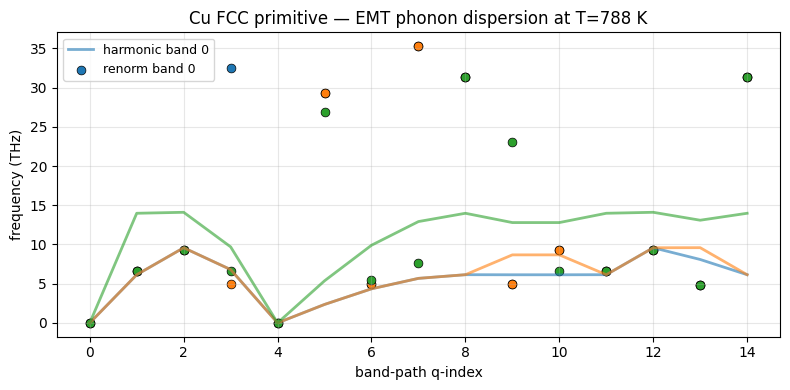

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
q_index = np.arange(out.q_points.shape[0])
for b in range(out.harmonic_frequencies.shape[1]):
    ax.plot(q_index, out.harmonic_frequencies[:, b], color=f"C{b}", lw=2, alpha=0.6,
            label=f"harmonic band {b}" if b == 0 else None)
    ax.scatter(q_index, out.renormalised_frequencies[:, b], color=f"C{b}", marker="o",
               s=40, edgecolor="black", linewidth=0.5,
               label=f"renorm band {b}" if b == 0 else None)
ax.set_xlabel("band-path q-index")
ax.set_ylabel("frequency (THz)")
ax.set_title("Cu FCC primitive — EMT phonon dispersion at T=788 K")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## What else the macro offers

- `q_points=None` (default) → auto-derived high-symmetry band path
  from `ase.dft.kpoints.bandpath`, useful for plotting dispersion.
- `phono3py_output=...` → reuse FC2 from a prior
  `calculate_phonon_thermal_conductivity` run, skipping the
  displacement-force fit entirely.
- `keep_handles=True` → keep the `dynaphopy.Quasiparticle`,
  `Dynamics`, and `phonopy.Phonopy` objects on `MdPhononOutput` for
  deeper inspection.
- `MdPhononOutput.check_md_health()` → flags ⟨T⟩ drift or σ_T anomalies;
  the macro auto-warns at completion if either heuristic trips.